# Univariate Exploratory Data Analysis (EDA)

In [9]:
# Upload dataset and read it into a pandas DataFrame
%pip install pandas
import pandas as pd

path = r"C:\Users\ramir\OneDrive\TMU Capstone\HR-Employee-Attrition-Dataset.csv"
df = pd.read_csv(path)
df.head()

Note: you may need to restart the kernel to use updated packages.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Dataset Overview & Data Integrity Checks
The IBM HR Analytics dataset contains 1470 rows and 35 columns, consisting primarily of int64 numerical variables and object categorical variables. A preliminary integrity review shows:
* No missing values
* No duplicate records
* Consistent datatypes appropriate for HR analytics

This indicates the dataset is clean and ready for exploratory analysis without additional preprocessing.

In [10]:
# Number of rows and columns
rows, cols = df.shape
print("Rows:", rows)
print("Columns:", cols)

Rows: 1470
Columns: 35


In [11]:
# Check data types of each column
df.dtypes

Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

In [12]:
# Check for missing/null values
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100
missing_summary = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
})

total_missing = missing_count.sum()
print("Total missing values:", total_missing)

if total_missing == 0:
    print("No missing/null values found in the dataset.")
else:
    print("\nMissing values by column:")
    display(missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False))
    print("\nSample rows with any missing values:")
    display(df[df.isnull().any(axis=1)].head())

Total missing values: 0
No missing/null values found in the dataset.


In [13]:
# Check for duplicate records
duplicate_count = df.duplicated().sum()
print("Number of duplicate records:", duplicate_count)

if duplicate_count == 0:
    print("No duplicate records found.")
else:
    print("\nSample duplicate rows:")
    display(df[df.duplicated()].head())

Number of duplicate records: 0
No duplicate records found.


## Univariate Distribution of Numerical Features

**Age**

Displays a roughly normal distribution, suggesting a balanced mix of early‑career and mid‑career employees.

**Right‑Skewed Features (Income & Tenure Variables)**

Several variables—including MonthlyIncome, TotalWorkingYears, YearsAtCompany, and YearsInCurrentRole—show right‑skewed distributions:
* Most employees fall at the lower end of these ranges
* A smaller group extends into much higher values
* This pattern often reflects organizational hierarchy (many junior staff, fewer senior leaders)

Right‑skewness is important because it may influence model assumptions and amplify the effect of high‑value outliers.

**Low‑Variance or Non‑Informative Features**

The following features show zero or near‑zero variance, making them candidates for removal during dimensionality reduction:

![Attribute Removal Table](image-1.png)

These features do not contribute meaningful signal and can be safely dropped.

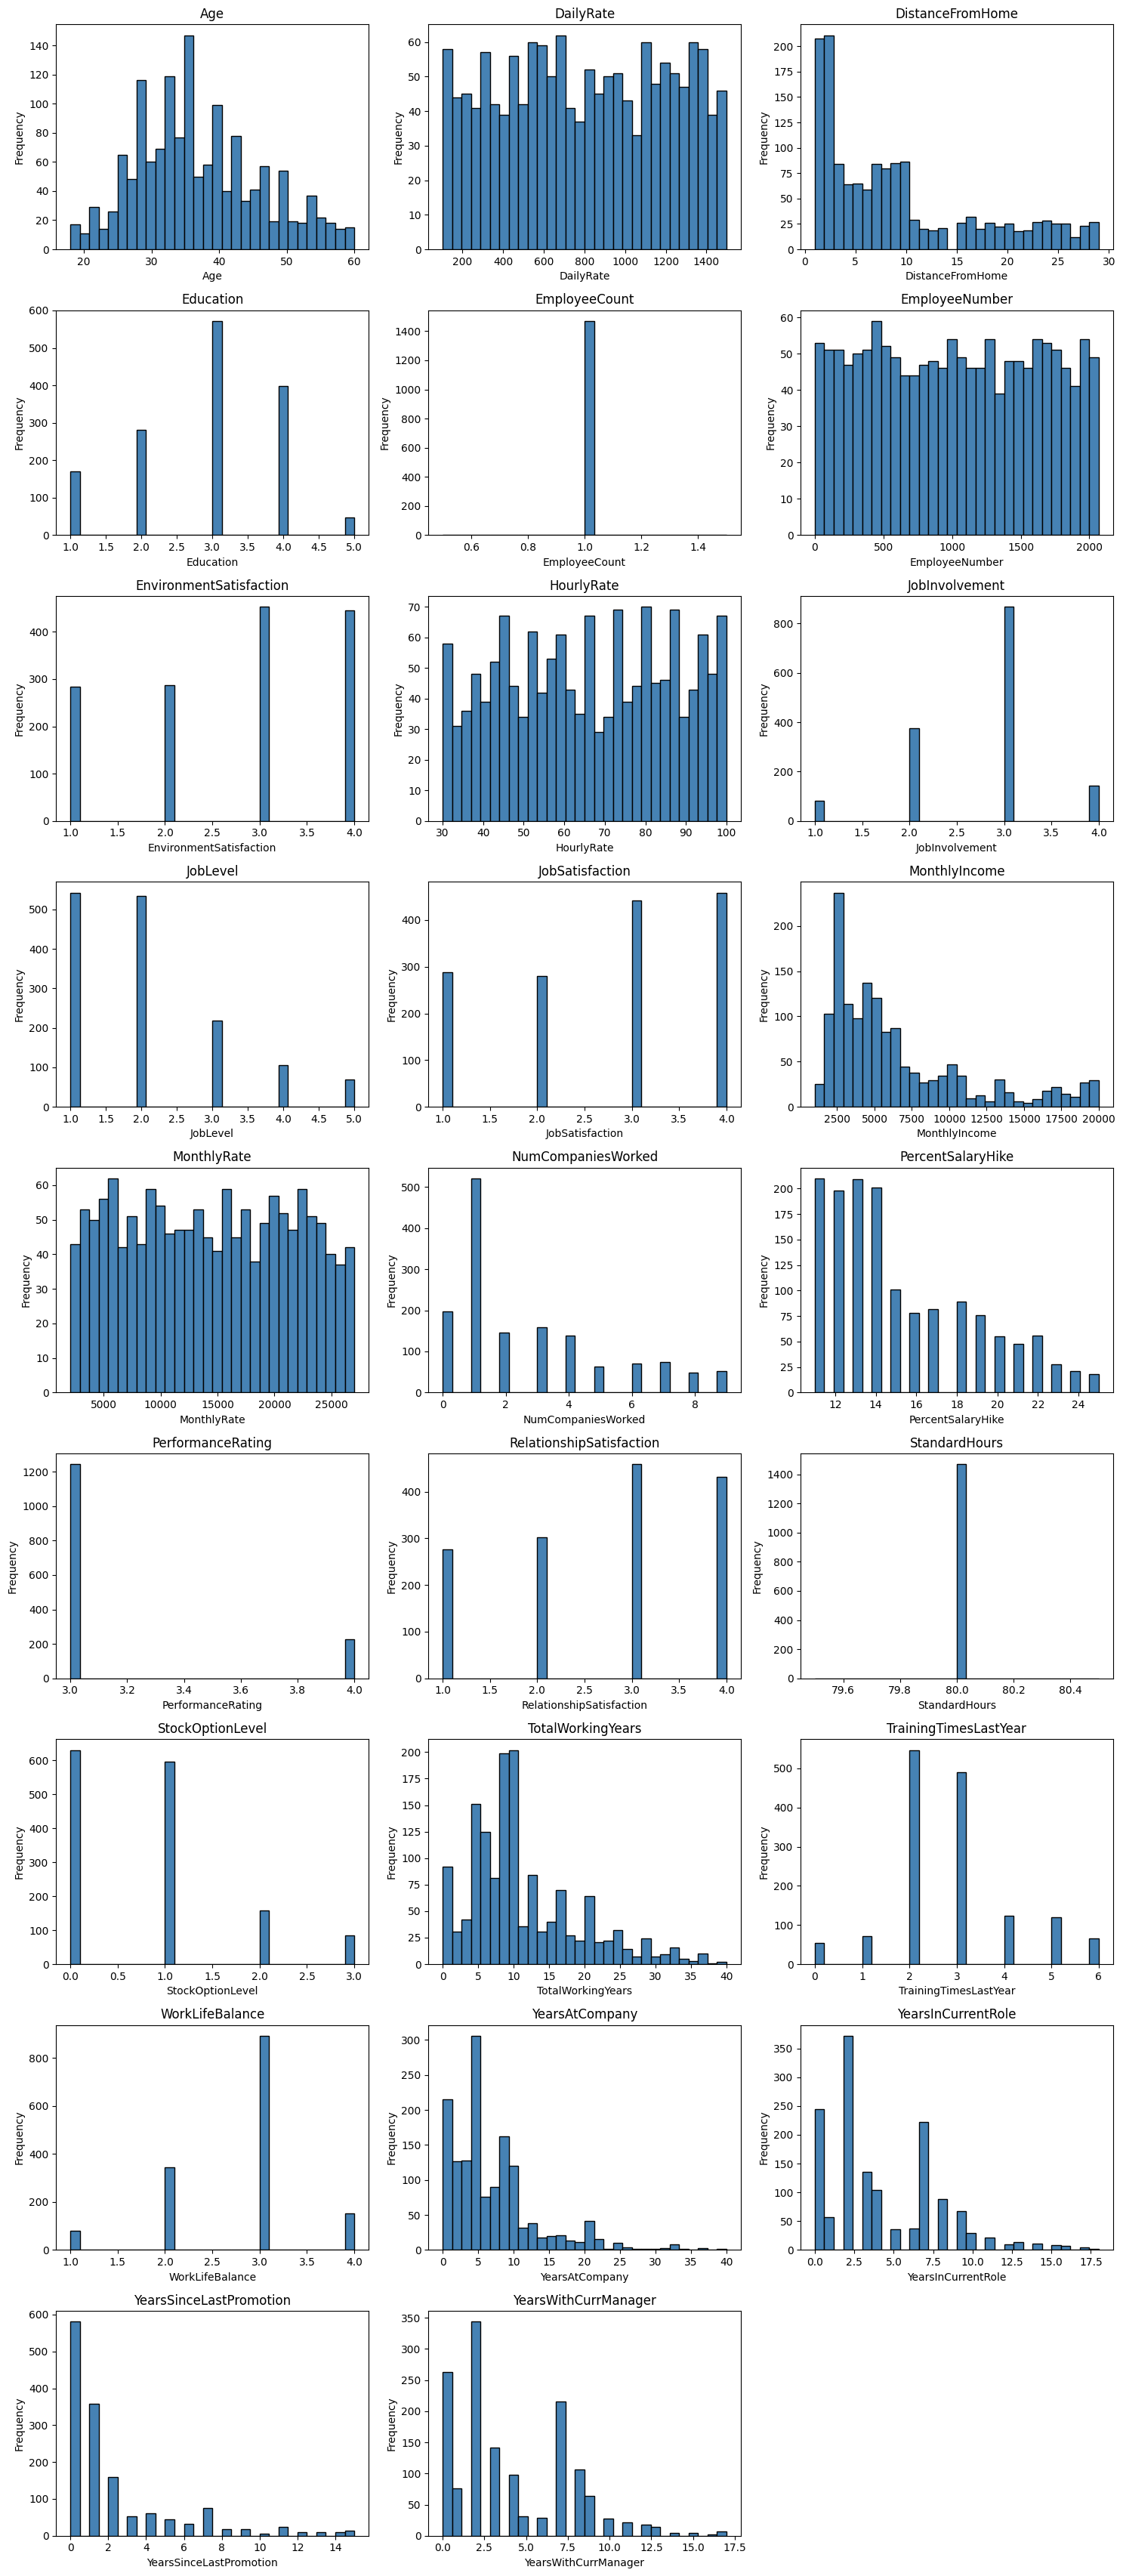

In [16]:
# Histograms for all numeric features (4 plots per row)
import matplotlib.pyplot as plt
num_cols = df.select_dtypes(include="number").columns

plots_per_row = 3
n_plots = len(num_cols)
n_rows = (n_plots + plots_per_row - 1) // plots_per_row

fig, axes = plt.subplots(n_rows, plots_per_row, figsize=(5 * plots_per_row, 3.8 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color="steelblue", edgecolor="black")
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## Outlier Detection via Boxplots
Boxplots reveal several high‑value outliers, each with meaningful HR interpretations:

![Outlier Attributes](image-2.png)

These outliers are not errors—they represent meaningful employee subgroups.

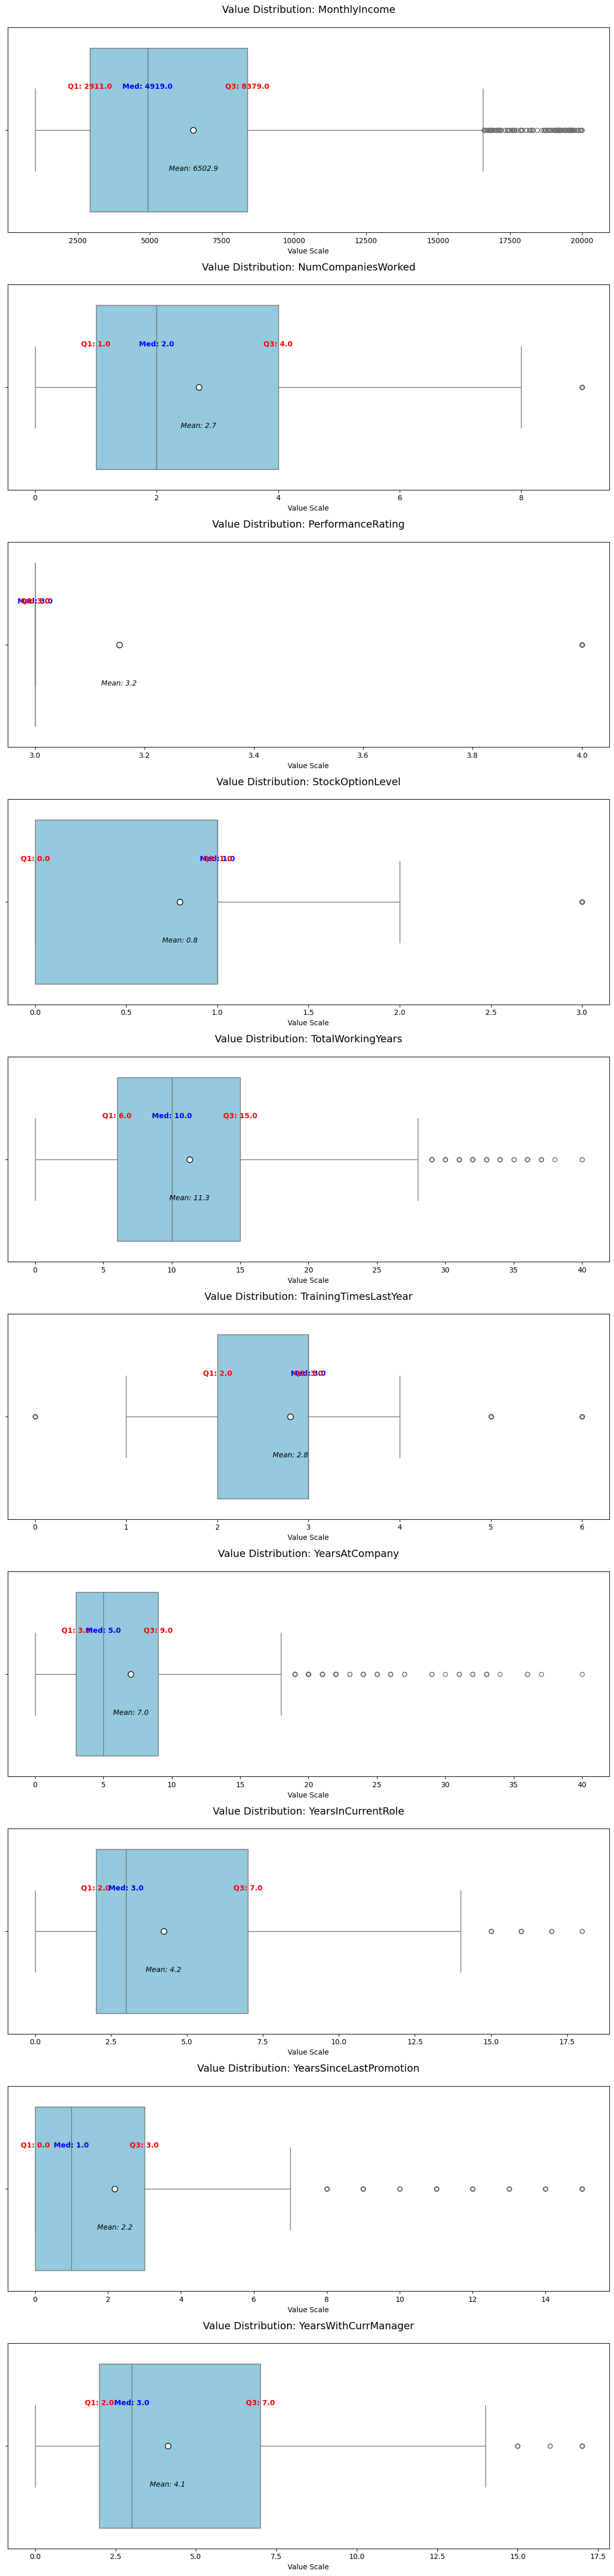

                                mean      Q1  Q2_Median      Q3      max
MonthlyIncome            6502.931293  2911.0     4919.0  8379.0  19999.0
NumCompaniesWorked          2.693197     1.0        2.0     4.0      9.0
PerformanceRating           3.153741     3.0        3.0     3.0      4.0
StockOptionLevel            0.793878     0.0        1.0     1.0      3.0
TotalWorkingYears          11.279592     6.0       10.0    15.0     40.0
TrainingTimesLastYear       2.799320     2.0        3.0     3.0      6.0
YearsAtCompany              7.008163     3.0        5.0     9.0     40.0
YearsInCurrentRole          4.229252     2.0        3.0     7.0     18.0
YearsSinceLastPromotion     2.187755     0.0        1.0     3.0     15.0
YearsWithCurrManager        4.123129     2.0        3.0     7.0     17.0


In [ ]:
# Boxplots of numeric features - outlier analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate stats and identify outliers
stats = df.describe().T
stats['Q1'] = stats['25%']
stats['Q2_Median'] = stats['50%']
stats['Q3'] = stats['75%']
stats['IQR'] = stats['Q3'] - stats['Q1']

# 2. Logic for Outlier Detection
stats['outlier_check'] = (stats['max'] > (stats['Q3'] + 1.5 * stats['IQR'])) | \
                         (stats['min'] < (stats['Q1'] - 1.5 * stats['IQR']))

outlier_cols = stats[stats['outlier_check'] == True].index.tolist()

# 3. Create subplots
n_cols = len(outlier_cols)
if n_cols > 0:
    fig, axes = plt.subplots(n_cols, 1, figsize=(12, 5 * n_cols))
    if n_cols == 1: axes = [axes]

    for i, col in enumerate(outlier_cols):
        # showmeans=True adds a marker for the average
        sns.boxplot(x=df[col], ax=axes[i], color='skyblue', showmeans=True, 
                    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})
        
        # Get the specific values for labeling
        q1, q2, q3 = stats.loc[col, ['Q1', 'Q2_Median', 'Q3']]
        mean_val = stats.loc[col, 'mean']
        
        # 4. Add Numeric Labels above the box
        # format(val, '.1f') rounds to 1 decimal place
        label_y_offset = -0.2  # Adjusts height of text above the box
        
        axes[i].text(q1, label_y_offset, f'Q1: {q1:.1f}', ha='center', fontweight='bold', color='red')
        axes[i].text(q2, label_y_offset, f'Med: {q2:.1f}', ha='center', fontweight='bold', color='blue')
        axes[i].text(q3, label_y_offset, f'Q3: {q3:.1f}', ha='center', fontweight='bold', color='red')
        axes[i].text(mean_val, 0.2, f'Mean: {mean_val:.1f}', ha='center', fontstyle='italic', color='black')

        axes[i].set_title(f'Value Distribution: {col}', fontsize=14, pad=20)
        axes[i].set_xlabel('Value Scale')

    plt.tight_layout()
    plt.show()

# 5. Summary Table
print(stats.loc[outlier_cols, ['mean', 'Q1', 'Q2_Median', 'Q3', 'max']])

In [ ]:
# Quick health check dataset

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


## Target Variable: Attrition Distribution
Attrition is highly imbalanced:
* No: 1233 employees (83.9%)
* Yes: 237 employees (16.1%)

This imbalance reflects real‑world turnover patterns but introduces modeling challenges:
* Models may become biased toward the majority class
* Resampling or class‑weighting strategies may be required

Because Attrition is categorical, it is best summarized using counts and percentages.

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----------------------- ---------------- 4.7/8.1 MB 23.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 24.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 21.9 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ------------------------------- -------- 5.5/7.0 MB 25.8 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 25.5 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- -----

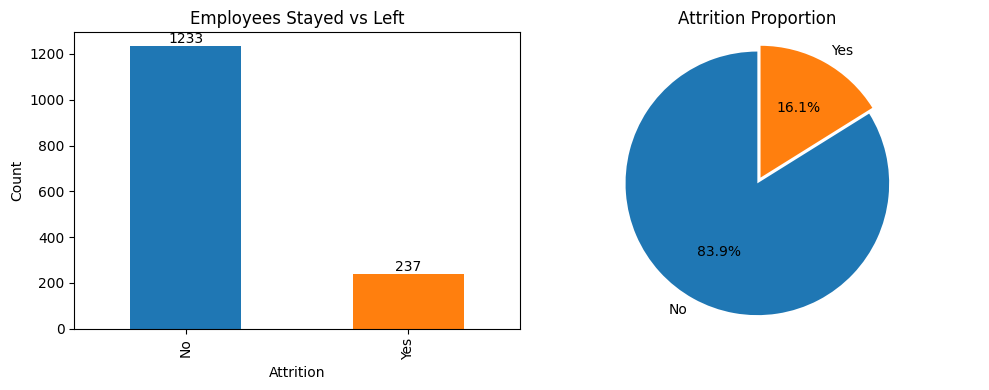

In [ ]:
#Distribution of employees who stayed vs left
%pip install matplotlib
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
attrition_counts.plot(kind='bar', ax=axes[0], color=['C0', 'C1'])
axes[0].set_title('Employees Stayed vs Left')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom')

# Pie chart
axes[1].pie(attrition_counts, labels=attrition_counts.index, autopct='%1.1f%%',
            colors=['C0', 'C1'], startangle=90, explode=(0, 0.05))
axes[1].set_title('Attrition Proportion')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

## Categorical Feature Distributions

**Business Travel**
* ~71% of employees travel rarely or not at all.

**Department & Education Field**
* Research & Development dominates (65.4%).
* Most employees have Life Sciences (41.2%) or Medical (31.6%) backgrounds.
* Sales is the second‑largest department (30.3%).

**Gender** 
* Workforce is 60% male and 40% female.

**Job Roles**

Top three roles:

* Sales Executive (22.2%)
* Research Scientist (19.9%)
* Laboratory Technician (17.6%)

**Marital Status**
* Married: 45.8%
* Single: 32%
* Divorced: 22.2%

**Overtime**
* Roughly one‑third of employees work overtime, a factor often linked to burnout and attrition.

**Over18**
* Constant “Y” → will be removed during dimensionality reduction.

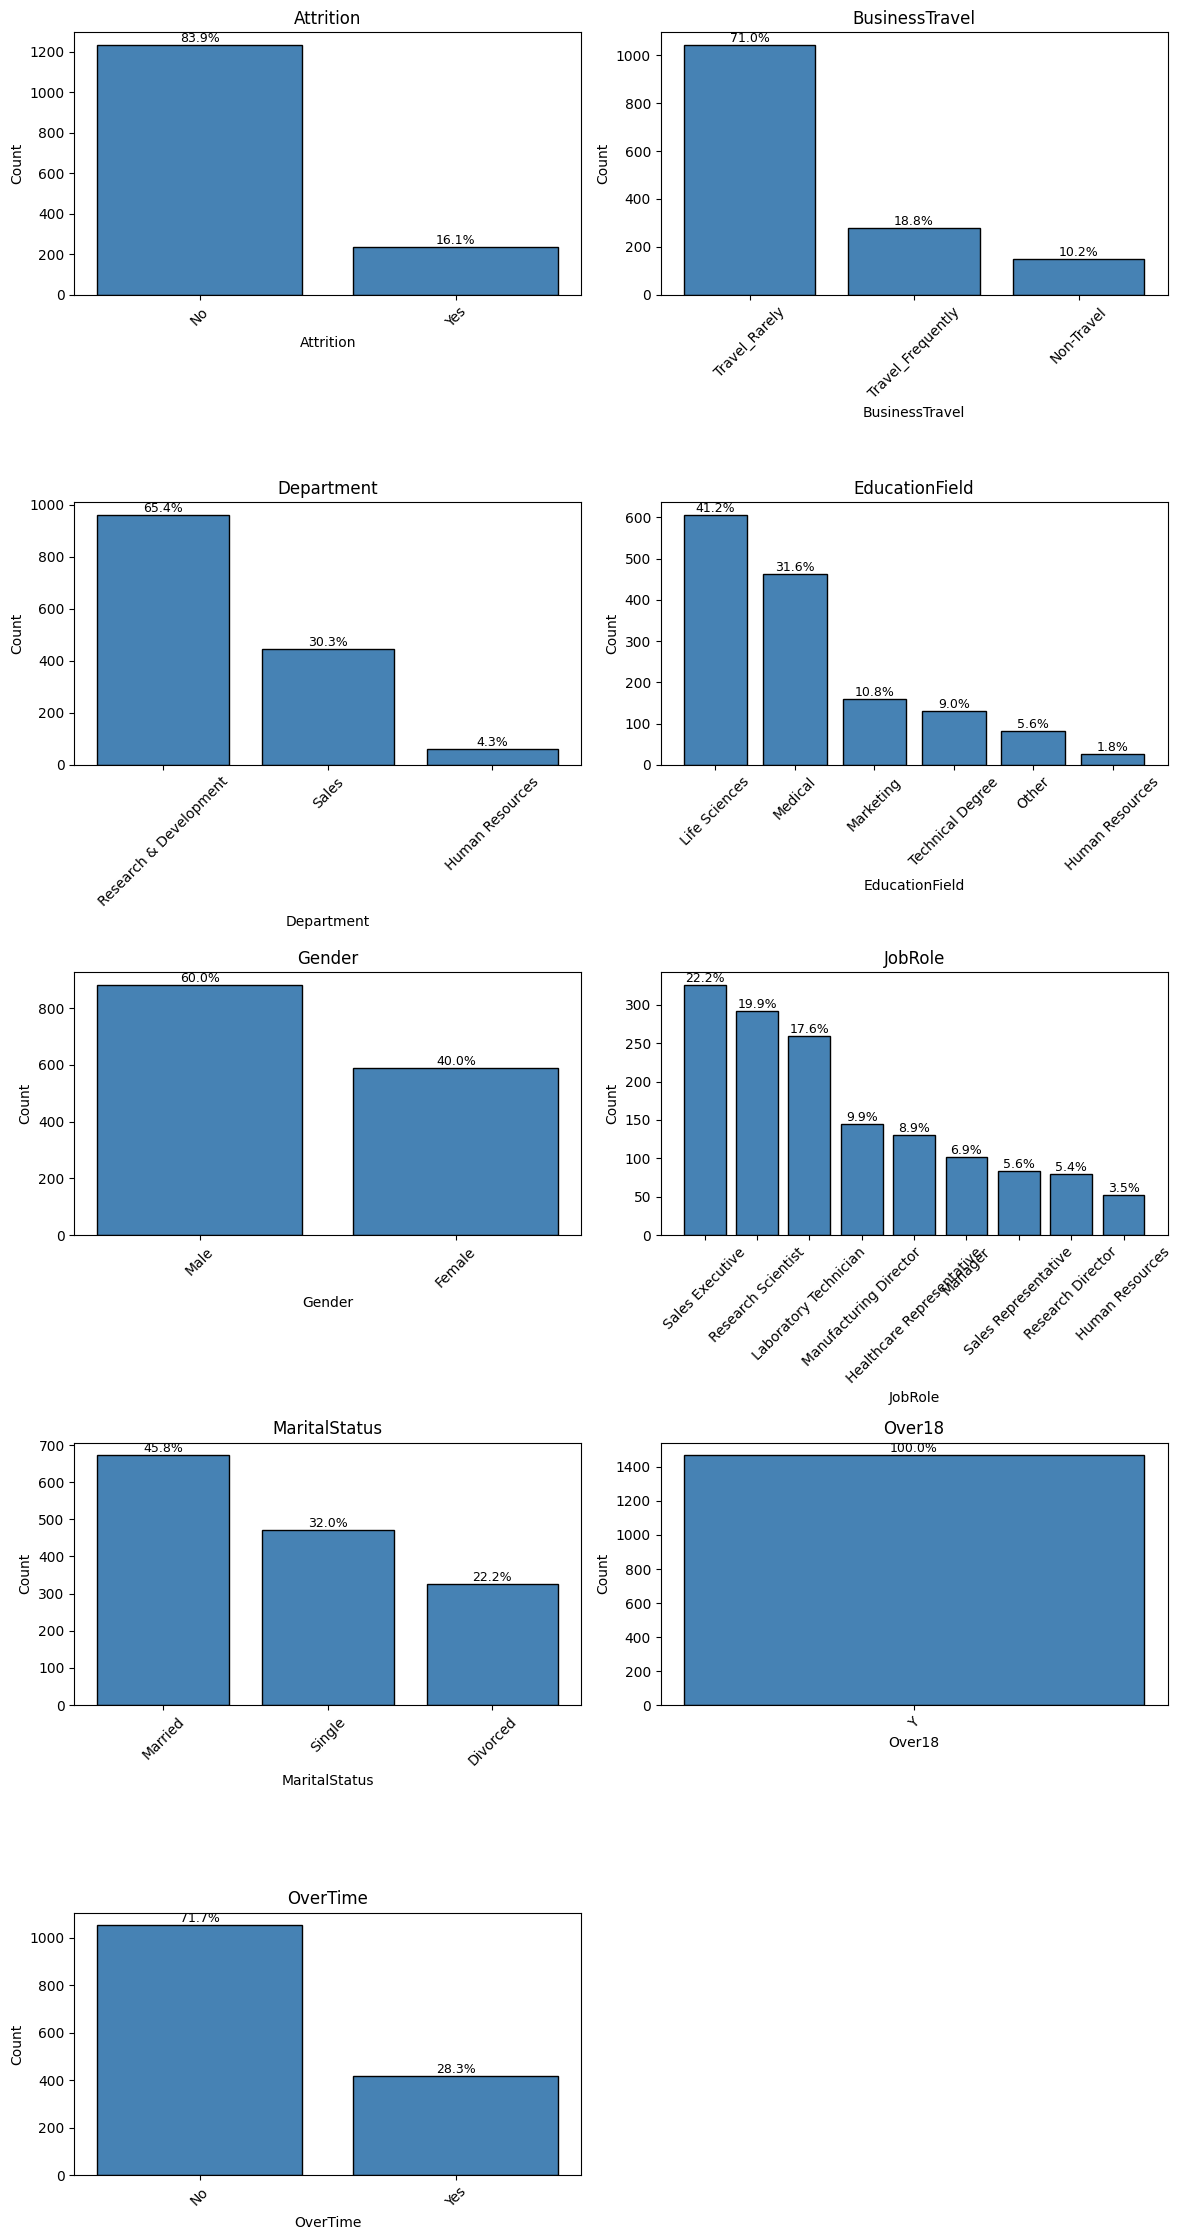

In [ ]:
# Distribution of categorical features with percentage labels (2 charts per row)

charts_per_row = 2
n_cols = len(cat_cols)
n_rows = (n_cols + charts_per_row - 1) // charts_per_row

fig, axes = plt.subplots(n_rows, charts_per_row, figsize=(6 * charts_per_row, 4.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts(dropna=False)
    percentages = (counts / counts.sum()) * 100

    bars = axes[i].bar(counts.index.astype(str), counts.values, color="steelblue", edgecolor="black")
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

    for bar, pct in zip(bars, percentages.values):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

# Hide unused subplot slots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Print unique values list for each column
for col in df.columns:
    uniques = df[col].unique().tolist()
    print(f"{col} (dtype={df[col].dtype}) - {len(uniques)} unique values")
    print(uniques)
    print("-" * 80)

Age (dtype=int64) - 43 unique values
[41, 49, 37, 33, 27, 32, 59, 30, 38, 36, 35, 29, 31, 34, 28, 22, 53, 24, 21, 42, 44, 46, 39, 43, 50, 26, 48, 55, 45, 56, 23, 51, 40, 54, 58, 20, 25, 19, 57, 52, 47, 18, 60]
--------------------------------------------------------------------------------
Attrition (dtype=str) - 2 unique values
['Yes', 'No']
--------------------------------------------------------------------------------
BusinessTravel (dtype=str) - 3 unique values
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
--------------------------------------------------------------------------------
DailyRate (dtype=int64) - 886 unique values
[1102, 279, 1373, 1392, 591, 1005, 1324, 1358, 216, 1299, 809, 153, 670, 1346, 103, 1389, 334, 1123, 1219, 371, 673, 1218, 419, 391, 699, 1282, 1125, 691, 477, 705, 924, 1459, 125, 895, 813, 1273, 869, 890, 852, 1141, 464, 1240, 1357, 994, 721, 1360, 1065, 408, 1211, 1229, 626, 1434, 1488, 1097, 1443, 515, 853, 1142, 655, 1115, 427, 653, 989, 1435, 

## Summary of Key Univariate EDA Findings
* Dataset is clean and ready for modeling
* Several numerical features are right‑skewed
* Multiple features show zero variance and should be removed
* Outliers represent meaningful employee subgroups
* Attrition is highly imbalanced (84% vs 16%)
* Workforce is dominated by R&D roles and Life Sciences backgrounds
* Overtime, job role, tenure, and income patterns show potential relationships with attrition
* These insights provide a strong foundation for correlation analysis, feature engineering, and predictive modeling.